# My Pandas Practice Notebook

This notebook is my own version of the "Pandas Practice for Data Science" lesson.
I followed the same overall flow as the instructor's notebook (Series, DataFrames,
loading CSVs, exploring, selecting, filtering, sorting, dropping, unique values, and a
chart), but I wrote every cell myself, used different example data, and added three
extra improvements that were not in the original notebook:

1. **Handling missing data** (dropna / fillna) on a real dataset that actually has NaNs.
2. **A custom function** applied with `.apply()` to create a brand-new column, combined with `.groupby()`.
3. **Two new chart types** (a histogram with a custom `bins` parameter, and a scatter plot).

Each improvement is marked with a `## Improvement` heading so it's easy to find.


## 1. Getting Started

In [1]:
# Import pandas under its standard nickname 'pd'
import pandas as pd
# numpy is used under the hood by pandas, and is handy for things like NaN
import numpy as np
# seaborn gives us some ready-made practice datasets and sits on top of matplotlib
import seaborn as sns
# matplotlib is the plotting engine pandas uses for its built-in .plot() method
import matplotlib.pyplot as plt
%matplotlib inline


## 2. Pandas Series

A Series is one labeled column of data. I'm using exam scores as my example.

In [2]:
# A Series built from a plain list gets an automatic 0,1,2,... index
exam_scores = pd.Series([88, 72, 95, 60, 79])
print(exam_scores)


0    88
1    72
2    95
3    60
4    79
dtype: int64


In [3]:
# I can attach my own labels with the 'index' parameter instead of 0,1,2,...
exam_scores = pd.Series([88, 72, 95, 60, 79],
                         index=["Alex", "Bao", "Chen", "Dara", "Evi"])
print(exam_scores)


Alex    88
Bao     72
Chen    95
Dara    60
Evi     79
dtype: int64


In [4]:
# A Series can also be created directly from a dictionary.
# Dictionary KEYS -> index labels, dictionary VALUES -> the data itself
grade_dict = {"Alex": "B+", "Bao": "C", "Chen": "A"}
grade_series = pd.Series(grade_dict)
print(grade_series)


Alex    B+
Bao      C
Chen     A
dtype: str


In [5]:
# Look up one student's score by their LABEL
print(exam_scores["Chen"])

# Look up the score in POSITION 1 (the second entry) using .iloc
print(exam_scores.iloc[1])


95
72


In [6]:
# Series come with built-in statistics methods - handy for a quick summary
print("min:", exam_scores.min())
print("max:", exam_scores.max())
print("mean:", exam_scores.mean())
print("median:", exam_scores.median())
# I added .std() here too, which was not shown in the original notebook
print("std (how spread out the scores are):", exam_scores.std())


min: 60
max: 95
mean: 78.8
median: 79.0
std (how spread out the scores are): 13.663820841916802


## 3. Pandas DataFrame

A DataFrame is a full table. I'm using a small list of my favorite books.

In [7]:
# Building a DataFrame from a dictionary: each key becomes a column
books = {
    "Title":  ["Dune", "1984", "The Hobbit", "Educated", "Sapiens"],
    "Year":   [1965, 1949, 1937, 2018, 2011],
    "Rating": [9.5, 9.0, 8.8, 9.2, 9.4]
}
books_df = pd.DataFrame(books)
books_df


,Title,Year,Rating
0,Dune,1965,9.5
1,1984,1949,9.0
2,The Hobbit,1937,8.8
3,Educated,2018,9.2
4,Sapiens,2011,9.4


In [8]:
# Building a DataFrame from a list of dictionaries - one dictionary per row.
# If a row is missing a key, pandas fills that cell with NaN (missing value)
reading_list = [
    {"Title": "Dune",       "Genre": "Sci-Fi",   "Pages": 412},
    {"Title": "1984",       "Genre": "Dystopian","Pages": 328},
    {"Title": "The Hobbit", "Genre": "Fantasy",  "Pages": 310},
    {"Pages": 254},                                    # 'Title' and 'Genre' missing -> NaN
    {"Title": "Sapiens",    "Genre": "History",  "Pages": 443},
]
reading_df = pd.DataFrame(reading_list)
reading_df


,Title,Genre,Pages
0,Dune,Sci-Fi,412
1,1984,Dystopian,328
2,The Hobbit,Fantasy,310
3,NaN,NaN,254
4,Sapiens,History,443


## 4. Exploring a DataFrame

The same four "first look" methods the lesson introduced, run on my books table.

In [9]:
# First 3 rows
books_df.head(3)


,Title,Year,Rating
0,Dune,1965,9.5
1,1984,1949,9.0
2,The Hobbit,1937,8.8


In [10]:
# Last 2 rows
books_df.tail(2)


,Title,Year,Rating
3,Educated,2018,9.2
4,Sapiens,2011,9.4


In [11]:
# Row count, column names, data types, and non-null counts
books_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Title   5 non-null      str    
 1   Year    5 non-null      int64  
 2   Rating  5 non-null      float64
dtypes: float64(1), int64(1), str(1)
memory usage: 252.0 bytes


In [12]:
# Summary statistics for every numeric column
books_df.describe()


,Year,Rating
count,5.00000,5.000000
mean,1976.00000,9.180000
std,36.60601,0.286356
min,1937.00000,8.800000
25%,1949.00000,9.000000
50%,1965.00000,9.200000
75%,2011.00000,9.400000
max,2018.00000,9.500000


## 5. Loading Real Data from a CSV File

I used a different real-world dataset than the lesson: the **Palmer Penguins** dataset, loaded straight from a URL.

In [13]:
penguins_url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"
penguins_data = pd.read_csv(penguins_url)
penguins_data.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [14]:
# Quick stats for the numeric columns: mean bill length, min body mass, etc.
penguins_data.describe()


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


### Improvement 1 - Handling Missing Data

The penguins dataset actually has real missing values (unlike the clean Iris dataset used
in the lesson), so this is a good place to practice `dropna()` and `fillna()`, which were
not covered in the original notebook.


In [15]:
# How many missing values does each column have?
penguins_data.isna().sum()


species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [16]:
# Option A: dropna() removes every row that has AT LEAST one missing value
penguins_no_na = penguins_data.dropna()
print("Rows before dropna:", len(penguins_data))
print("Rows after dropna:", len(penguins_no_na))


Rows before dropna: 344
Rows after dropna: 333


In [17]:
# Option B: fillna() keeps every row, but fills the gaps in instead.
# I fill the numeric measurement columns with that column's own mean,
# and I fill the missing 'sex' values with the label "unknown"
penguins_filled = penguins_data.copy()
numeric_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
for col in numeric_cols:
    penguins_filled[col] = penguins_filled[col].fillna(penguins_filled[col].mean())
penguins_filled["sex"] = penguins_filled["sex"].fillna("unknown")

# Confirm there are no more missing values left
penguins_filled.isna().sum()


species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

## 6. The Tips Dataset

Instead of the Titanic dataset, I used seaborn's built-in **tips** dataset (restaurant bills and tips) for the rest of the notebook.

In [18]:
# Load the built-in 'tips' dataset - each row is one restaurant bill
tips_data = sns.load_dataset("tips")
tips_data.head()


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [19]:
# How many rows and columns?
print(tips_data.shape)


(244, 7)


## 7. Selecting Columns with `[]`

In [20]:
# One column name -> a Series
bill_column = tips_data["total_bill"]
print(type(bill_column))
bill_column.head()


<class 'pandas.Series'>


0    16.99
1    10.34
2    21.01
3    23.68
4    24.59
Name: total_bill, dtype: float64

In [21]:
# A list of column names -> a smaller DataFrame
subset = tips_data[["day", "time", "total_bill", "tip"]]
subset.head()


,day,time,total_bill,tip
0,Sun,Dinner,16.99,1.01
1,Sun,Dinner,10.34,1.66
2,Sun,Dinner,21.01,3.50
3,Sun,Dinner,23.68,3.31
4,Sun,Dinner,24.59,3.61


## 8. Filtering Rows by a Condition

In [22]:
# Keep only dinner-time bills
dinner_bills = tips_data[tips_data["time"] == "Dinner"]
dinner_bills.head()


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [23]:
# Combine two conditions with '&': dinner time AND the party did not smoke
dinner_nonsmokers = tips_data[
    (tips_data["time"] == "Dinner") &
    (tips_data["smoker"] == "No")
]
dinner_nonsmokers.head()


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [24]:
# .isin() keeps rows whose value is inside a given list - great for "any of these"
weekend_days = ["Sat", "Sun"]
weekend_bills = tips_data[tips_data["day"].isin(weekend_days)]
weekend_bills.head()


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## 9. Selecting Rows and Columns with `.loc` (by LABEL)

I built a small weekly-sales table with custom row labels to practice `.loc`.

In [25]:
sales_records = [
    {"Product": "Notebook", "UnitsSold": 120, "Revenue": 480, "Rating": "A"},
    {"Product": "Pen",      "UnitsSold": 300, "Revenue": 150, "Rating": "B"},
    {"Product": "Backpack", "UnitsSold": 40,  "Revenue": 1200,"Rating": "A"},
    {"Product": "Eraser",   "UnitsSold": 500, "Revenue": 100, "Rating": "C"},
    {"Product": "Ruler",    "UnitsSold": 90,  "Revenue": 90,  "Rating": "B"},
]
sales_df = pd.DataFrame(sales_records,
                         index=["Week1", "Week2", "Week3", "Week4", "Week5"])
sales_df


,Product,UnitsSold,Revenue,Rating
Week1,Notebook,120,480,A
Week2,Pen,300,150,B
Week3,Backpack,40,1200,A
Week4,Eraser,500,100,C
Week5,Ruler,90,90,B


In [26]:
# One row by its label -> a Series
sales_df.loc["Week1"]


Product      Notebook
UnitsSold         120
Revenue           480
Rating              A
Name: Week1, dtype: object

In [27]:
# Slice by label - with .loc BOTH ends are included
sales_df.loc["Week1":"Week3"]


,Product,UnitsSold,Revenue,Rating
Week1,Notebook,120,480,A
Week2,Pen,300,150,B
Week3,Backpack,40,1200,A


In [28]:
# .loc takes [row labels, column names] together
sales_df.loc["Week1":"Week4", ["Product", "Revenue"]]


,Product,Revenue
Week1,Notebook,480
Week2,Pen,150
Week3,Backpack,1200
Week4,Eraser,100


In [29]:
# .loc also accepts a boolean condition, e.g. weeks with Revenue over 100
sales_df.loc[sales_df["Revenue"] > 100, ["Product", "Revenue"]]


,Product,Revenue
Week1,Notebook,480
Week2,Pen,150
Week3,Backpack,1200


## 10. Selecting with `.iloc` (by POSITION)

In [30]:
# Row at position 2 (the 3rd row), ignoring its label
sales_df.iloc[2]


Product      Backpack
UnitsSold          40
Revenue          1200
Rating              A
Name: Week3, dtype: object

In [31]:
# Positions 1 to 3 (3 excluded) and columns 0 to 2 (2 excluded)
sales_df.iloc[1:3, 0:2]


,Product,UnitsSold
Week2,Pen,300
Week3,Backpack,40


## 11. Dropping Rows and Columns

In [32]:
# Rebuild with a default integer index so drop-by-position-label is easy to read
sales_default_index = pd.DataFrame(sales_records)

# Drop rows 0 and 3 (axis=0 = rows)
fewer_rows = sales_default_index.drop([0, 3], axis=0)
fewer_rows


,Product,UnitsSold,Revenue,Rating
1,Pen,300,150,B
2,Backpack,40,1200,A
4,Ruler,90,90,B


In [33]:
# Drop the 'Rating' column entirely (axis=1 = columns)
fewer_cols = sales_default_index.drop(["Rating"], axis=1)
fewer_cols


,Product,UnitsSold,Revenue
0,Notebook,120,480
1,Pen,300,150
2,Backpack,40,1200
3,Eraser,500,100
4,Ruler,90,90


## 12. Sorting a DataFrame

In [34]:
# Cheapest bills first (ascending is the default)
by_bill = tips_data.sort_values(by="total_bill")
by_bill.head()


,total_bill,tip,sex,smoker,day,time,size
67,3.07,1.00,Female,Yes,Sat,Dinner,1
92,5.75,1.00,Female,Yes,Fri,Dinner,2
111,7.25,1.00,Female,No,Sat,Dinner,1
172,7.25,5.15,Male,Yes,Sun,Dinner,2
149,7.51,2.00,Male,No,Thur,Lunch,2


In [35]:
# Biggest tips first
by_tip_desc = tips_data.sort_values(by="tip", ascending=False)
by_tip_desc.head()


,total_bill,tip,sex,smoker,day,time,size
170,50.81,10.00,Male,Yes,Sat,Dinner,3
212,48.33,9.00,Male,No,Sat,Dinner,4
23,39.42,7.58,Male,No,Sat,Dinner,4
59,48.27,6.73,Male,No,Sat,Dinner,4
141,34.30,6.70,Male,No,Thur,Lunch,6


In [36]:
# Sort by TWO columns: day first, then by total_bill (highest first) as a tiebreaker
multi_sort = tips_data.sort_values(by=["day", "total_bill"], ascending=[True, False])
multi_sort.head()


,total_bill,tip,sex,smoker,day,time,size
197,43.11,5.00,Female,Yes,Thur,Lunch,4
142,41.19,5.00,Male,No,Thur,Lunch,5
85,34.83,5.17,Female,No,Thur,Lunch,4
141,34.30,6.70,Male,No,Thur,Lunch,6
83,32.68,5.00,Male,Yes,Thur,Lunch,2


## 13. Unique Values and Counts

In [37]:
# Which different days appear in the data?
tips_data["day"].unique()


['Sun', 'Sat', 'Thur', 'Fri']
Categories (4, str): ['Thur', 'Fri', 'Sat', 'Sun']

In [38]:
# How many different days is that?
tips_data["day"].nunique()


4

In [39]:
# How many bills happened on each day? (sorted, most common first)
tips_data["day"].value_counts()


day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

In [40]:
# Non-null value count for every column
tips_data.count()


total_bill    244
tip           244
sex           244
smoker        244
day           244
time          244
size          244
dtype: int64

### Improvement 2 - A Custom Function with `.apply()` and `.groupby()`

The lesson never wrote a custom function. Here I write one that labels each bill's
tip percentage as "Low", "Medium", or "High", apply it to every row to build a new
column, and then use `.groupby()` (also new) to compare average bills across the groups.


In [41]:
def tip_category(row):
    """Return a label describing how generous the tip was, as a % of the bill."""
    tip_percent = row["tip"] / row["total_bill"] * 100
    if tip_percent < 15:
        return "Low"
    elif tip_percent < 20:
        return "Medium"
    else:
        return "High"

# axis=1 tells apply() to run the function once per ROW
tips_data["tip_category"] = tips_data.apply(tip_category, axis=1)
tips_data[["total_bill", "tip", "tip_category"]].head()


,total_bill,tip,tip_category
0,16.99,1.01,Low
1,10.34,1.66,Medium
2,21.01,3.50,Medium
3,23.68,3.31,Low
4,24.59,3.61,Low


In [42]:
# Now group by the new column and compare average bill size in each group
tips_data.groupby("tip_category")["total_bill"].mean()


tip_category
High      15.877692
Low       22.659907
Medium    18.157423
Name: total_bill, dtype: float64

## 14. Bonus - Quick Charts

<Axes: title={'center': 'Bills per Day'}, xlabel='day'>

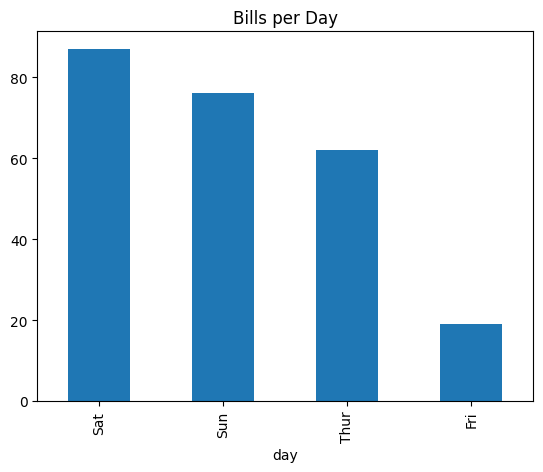

In [43]:
# Same style of chart as the lesson: counts per category as a bar chart
tips_data["day"].value_counts().plot(kind="bar", title="Bills per Day")


### Improvement 3 - New Chart Types and a Different Parameter

The lesson only showed one bar chart. I added a histogram (a chart type that never
appeared in the original notebook) and tried a non-default `bins` parameter, plus a
scatter plot to see the relationship between two numeric columns.


Text(0.5, 0, 'Total Bill ($)')

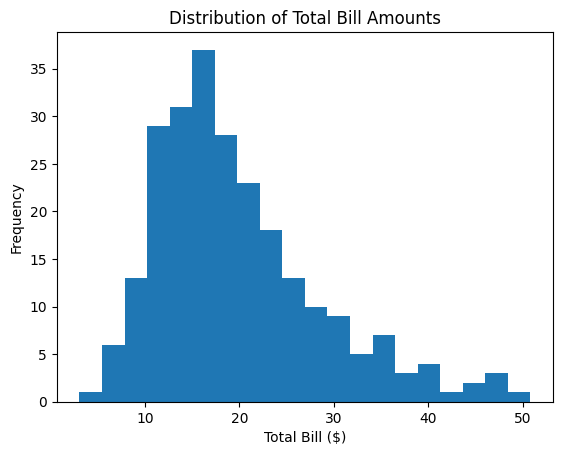

In [44]:
# Histogram of total_bill, using 20 bins instead of pandas' default of 10
tips_data["total_bill"].plot(kind="hist", bins=20, title="Distribution of Total Bill Amounts")
plt.xlabel("Total Bill ($)")


<Axes: title={'center': 'Tip vs. Total Bill'}, xlabel='total_bill', ylabel='tip'>

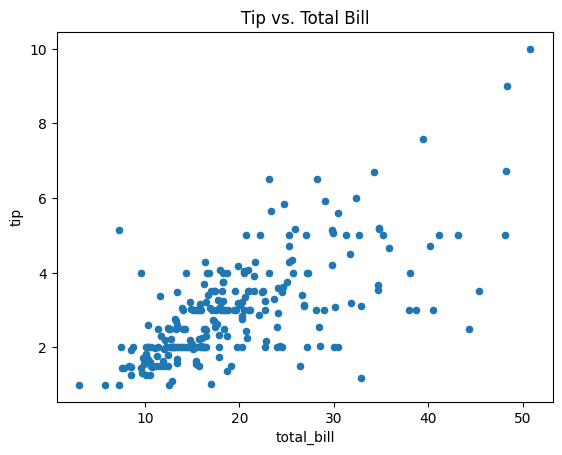

In [45]:
# Scatter plot: does a bigger bill mean a bigger tip?
tips_data.plot(kind="scatter", x="total_bill", y="tip", title="Tip vs. Total Bill")


## Reflection

The original notebook was a beginner-friendly tour of the core Pandas workflow: building
Series and DataFrames from scratch, loading real data from a CSV/URL, exploring it with
`head`/`tail`/`info`/`describe`, then selecting, filtering, sorting, dropping, and
summarizing columns before making a quick chart. To make this version genuinely mine, I
rebuilt every example with different data (books and weekly sales instead of student
scores, the Palmer Penguins and restaurant Tips datasets instead of Iris and Titanic) and
wrote my own comments explaining each step in my own words rather than reusing the
lesson's. I also added three things the original never covered: handling real missing
values with `dropna()`/`fillna()`, writing a custom function and applying it row-by-row
with `.apply()` combined with `.groupby()` to summarize the result, and two new chart
types (a histogram with a custom `bins` value and a scatter plot) instead of just the one
bar chart. Working through this taught me that `.loc` and `.iloc` are easy to mix up
because `.loc` includes the last label in a slice while `.iloc` excludes the last
position, and that boolean filtering and `.loc` with a condition end up doing very
similar jobs. I also learned that real-world data (like the penguins dataset) almost
always has missing values, so `fillna()`/`dropna()` are tools I'll reach for constantly,
not just an edge case. Overall this exercise made the difference between "recognizing"
pandas syntax when I read it and actually being able to write it myself from a blank
notebook.
